<img src='http://drive.google.com/uc?export=view&id=1Lv8NU_SuGQ9uVjU8N6_NwNi72qbSnbQL'>

# Group Members

Tony Steere (10077801)

Bhuvan Dubey (30139765)

Andrew Gellner (30027843)  

Lovette Daminabo (301381)

# <font color='lightblue'>Exploratory Data Analysis</font>

In this project you will perform an exploritory data analysis (EDA) using visualizations and correlations. You may choose from one of the datasets within the [class shared data folder](https://drive.google.com/drive/folders/1s2Civxvys_SR1sFF7D2ept1GSmFbICQb?usp=sharing), or search for a dataset that interests you the most! [Kaggle](https://www.kaggle.com/datasets?fileType=csv) is a good place to start, as they often have relatively clean and easy to use datasets, but feel free to explore other places. There is a lot of data out there!

In this project you will:

1.  Choose and download a dataset
2.  Get summary statistics for key variables
3.  Create visuals to help understand your data
4.  Use correlation to measure relationships between key variables
5.  Summarise how EDA helped (or not!) in understanding your dataset



# Import libraries


In [ ]:
!pip install mapclassify


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 15.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import numpy as np
from geopandas import sjoin_nearest
from shapely.geometry import Point
import plotly.express as px
import requests

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# <font color='lightblue'>1. Load Data </font>

**Action:** Import your data into colaboratory.


## Load Files

### List available geojson files in the shared drive

In [ ]:
fileList = !ls "/content/drive/MyDrive/DATA 601 " #List all the files in the project folder
gj_files = [file for file in fileList if file.endswith(".geojson")]
gj_files

[' Calgary_Bikeways_20250917.geojson',
 ' Calgary_Equity_Index_Overlay_Statistics_20250917.geojson',
 ' Speed_Limits_20250917.geojson',
 ' Traffic_Incidents_20250915.geojson',
 ' Traffic_Volumes_for_2024_20250915.geojson']

### File 1 = Traffic Incidents

In [ ]:
######File 1 = Traffic Incidents#######

url_initial = "https://data.calgary.ca/resource/35ra-9556.geojson"
chunks = []
limit = 25000
offset = 0

while True:
    url = f"{url_initial}?$limit={limit}&$offset={offset}"
    gdf = gpd.read_file(url)
    if gdf.empty:
        break
    chunks.append(gdf)
    offset += limit

df_incidents = pd.concat(chunks, ignore_index=True)

print(f"Number of rows in df_incidents: {len(df_incidents)}")

try:
  dropColumns = [':id', ':version', ':created_at', ':updated_at', 'count',':@computed_region_kxmf_bzkv',':@computed_region_4a3i_ccfj', ':@computed_region_4b54_tmc4']
  df_incidents = df_incidents.drop(columns=dropColumns) #drop all of the columns that match the above list
except:
  pass

try:
  orderColumns = ['id','geometry', 'latitude', 'longitude', 'start_dt', 'modified_dt', 'quadrant', 'incident_info', 'description']
  df_incidents = df_incidents[orderColumns] #set a specific column order
  renameColumns = {'id':'Traffic Incident ID','latitude':'Latitude', 'longitude':'Longitude', 'start_dt':'Traffic Incident Start Date', 'modified_dt':'Traffic Incident Modified Date', 'quadrant':'City Quadrant', 'incident_info':'Traffic Incident Info', 'description':'Traffic Incident Description'}
  df_incidents = df_incidents.rename(columns=renameColumns) #rename the columns for format and precision
except:
  pass

#df_incidents = df_incidents.to_crs(epsg=3857) #convert to geographic reference
df_incidents['Year'] = pd.to_datetime(df_incidents['Traffic Incident Start Date']).dt.year #extract the year from the date column

filteryears = [2023,2024,2025]
df_incidents = df_incidents[df_incidents['Year'].isin(filteryears)]

#df_incidents.crs
df_incidents.geometry = df_incidents.geometry.to_crs(epsg=4326)

print(f"Number of rows in df_incidents after filtering to years {filteryears}: {len(df_incidents)}")

df_incidents

Number of rows in df_incidents: 56393
Number of rows in df_incidents after filtering to years [2023, 2024, 2025]: 19267


,Traffic Incident ID,geometry,Latitude,Longitude,Traffic Incident Start Date,Traffic Incident Modified Date,City Quadrant,Traffic Incident Info,Traffic Incident Description,Year
0,2025-09-24T06:28:0251.05328496114677-113.95643...,POINT (-113.95644 51.05328),51.05328496114677,-113.95643971217591,2025-09-24 06:28:02,2025-09-24 06:31:08,NE,Southbound 52 Street and Memorial Drive NE,Two vehicle incident. Blocking the left turn lane,2025
1,2025-09-24T05:21:3550.98951003893828-113.96422...,POINT (-113.96423 50.98951),50.98951003893828,-113.96422550246585,2025-09-24 05:21:35,2025-09-24 06:31:08,SE,72 Avenue and 48 Street SE,Traffic incident.,2025
2,2025-09-23T21:44:1350.89589293007678-113.99125...,POINT (-113.99125 50.89589),50.89589293007678,-113.99125497926853,2025-09-23 21:44:13,2025-09-23 21:48:36,SE,Cranston Boulevard at Stoney Trail SE,Traffic incident. Blocking multiple lanes in t...,2025
3,2025-09-23T20:36:4951.110542433763605-114.0419...,POINT (-114.04191 51.11054),51.110542433763605,-114.04191076567339,2025-09-23 20:36:49,2025-09-23 21:15:28,NE,Eastbound 64 Avenue and 9 Street NE,Traffic incident. Blocking the right lane,2025
4,2025-09-23T20:22:1151.06859313808362-114.12916...,POINT (-114.12916 51.06859),51.06859313808362,-114.12916141151824,2025-09-23 20:22:11,2025-09-23 20:38:32,NW,16 Avenue and Uxbridge Drive NW,Traffic incident.,2025
...,...,...,...,...,...,...,...,...,...,...
19262,2023-01-01T12:29:0151.153741935174665-113.9697...,POINT (-113.96976 51.15374),51.153741935174665,-113.96976004505208,2023-01-01 12:29:01,2023-01-01 12:30:11,NE,Country Hills Boulevard and Metis Trail NE,Multi-vehicle incident. Blocking the NB left l...,2023
19263,2023-01-01T04:20:0551.069400435387976-114.0715...,POINT (-114.07151 51.0694),51.069400435387976,-114.07151225322856,2023-01-01 04:20:05,2023-01-01 04:21:17,NW,4 Street and 19 Avenue NW,Traffic incident.,2023
19264,2023-01-01T01:52:5751.06684662406409-113.94084...,POINT (-113.94084 51.06685),51.06684662406409,-113.94084084992373,2023-01-01 01:52:57,2023-01-01 02:28:28,NE,Eastbound 16 Avenue approaching 68 Street NE,Multi-vehicle incident. Blocking the left lanes,2023
19265,2023-01-01T01:46:4951.04237001620792-114.06250...,POINT (-114.0625 51.04237),51.04237001620792,-114.0625002958673,2023-01-01 01:46:49,2023-01-01 02:28:28,SW,Westbound 11 Avenue at Centre Street S,Traffic incident. Blocking the left lanes,2023


### File 2 - Traffic Volumes

In [ ]:
######File 2 = Traffic Volumes#######
url_initial = "https://data.calgary.ca/resource/cauu-7hnw.geojson"
chunks = []
limit = 25000
offset = 0

while True:
    url = f"{url_initial}?$limit={limit}&$offset={offset}"
    gdf = gpd.read_file(url)
    if gdf.empty:
        break
    chunks.append(gdf)
    offset += limit

df_volumes = pd.concat(chunks, ignore_index=True)

try:
  dropColumns = [':id', ':version', ':created_at', ':updated_at', 'collection', 'section', 'shape_length']
  df_volumes = df_volumes.drop(columns=dropColumns)
except:
  pass

try:
  orderColumns = ['geometry', 'year', 'volume', 'section_name']
  df_volumes = df_volumes[orderColumns]
  renameColumns = {'year':'Year', 'volume':'Traffic Volume', 'section_name':'Section Name'}
  df_volumes = df_volumes.rename(columns=renameColumns) #rename the columns for format and precision
except:
  pass

df_volumes.geometry = df_volumes.geometry.to_crs(epsg=4326)
##Initial strategy was centroid (central point of each road path). Andrew's implentation found that multi-coordinate paths also work with sjoin nearest
#df_volumes['geometry'] = df_volumes.geometry.centroid #in traffic volumes, the geographic coordinates are a path/shape. This operation collapses those coordinates to their center
df_volumes['Year'] = df_volumes['Year'].astype(int)

print(f"Number of rows in df_volumes: {len(df_volumes)}")

Number of rows in df_volumes: 334


In [ ]:
# Preprocessing: Extract coordinates and explode MultiLineStrings into individual points

# Create a list to store the new rows with exploded coordinates
rows_list = []

for index, row in df_volumes.iterrows():
    geom = row.geometry
    section_name = row['Section Name']
    traffic_volume = row['Traffic Volume']
    year = row['Year']

    if geom.geom_type == 'MultiLineString':
        for line in geom.geoms:
            for x, y in line.coords:
                rows_list.append({
                    'Section Name': section_name,
                    'Traffic Volume': traffic_volume,
                    'Year': year,
                    'geometry': Point(x, y), # Store as Point geometry
                    'lon': x,
                    'lat': y
                })
    elif geom.geom_type == 'LineString':
        for x, y in geom.coords:
             rows_list.append({
                'Section Name': section_name,
                'Traffic Volume': traffic_volume,
                'Year': year,
                'geometry': Point(x, y), # Store as Point geometry
                'lon': x,
                'lat': y
            })

# Create a new GeoDataFrame from the list of rows
df_volumes_points = gpd.GeoDataFrame(rows_list, crs=df_volumes.crs)
df_volumes.geometry = df_volumes.geometry.to_crs(epsg=4326)

# Display the first few rows of the new dataframe
display(df_volumes_points.head())

,Section Name,Traffic Volume,Year,geometry,lon,lat
0,14STSW1,49000.0,2024,POINT (-114.09473 50.98811),-114.094727,50.988112
1,14STSW1,49000.0,2024,POINT (-114.09473 50.98815),-114.094726,50.988149
2,14STSW1,49000.0,2024,POINT (-114.09473 50.98818),-114.094726,50.988175
3,14STSW1,49000.0,2024,POINT (-114.09473 50.98886),-114.094730,50.988862
4,14STSW1,49000.0,2024,POINT (-114.09473 50.98893),-114.094730,50.988931


### File 3 - Equity Index

In [ ]:
#####File 3 = Equity Index Overlay Statistics#######
filename_load = "/content/drive/MyDrive/DATA 601 /Calgary_Equity_Index_Overlay_Statistics_20250917.geojson"
df_income = gpd.read_file(filename_load)

try:
  dropColumns = [':id', ':version', ':created_at', ':updated_at', 'shape_length']
  df_income = df_income.drop(columns=dropColumns)
except:
  pass

print("Columns before renaming:", df_income.columns)

try:
  orderColumns = ['geometry', 'value', 'value_label', 'ranking', 'attribute', 'category', 'area_type', 'area_id', 'data_currency']
  df_income = df_income[orderColumns]
  renameColumns = {'value':'Equity Index Value', 'value_label':'Equity Index Label', 'ranking':'Equity Index Ranking'}
  df_income = df_income.rename(columns=renameColumns)
except Exception as e:
    print(f"An error occurred during renaming or column reordering: {e}")


df_income = df_income.to_crs(epsg=3857)
requested_columns = ['Equity Index Value', 'Equity Index Label', 'Equity Index Ranking', 'geometry']
display(df_income.loc[:, requested_columns].head())

Columns before renaming: Index(['attribute', 'category', 'value', 'value_label', 'area_type', 'area_id',
       'ranking', 'data_currency', ':id', ':version', ':created_at',
       ':updated_at', 'geometry'],
      dtype='object')


,Equity Index Value,Equity Index Label,Equity Index Ranking,geometry
0,54556.2464,"$54,556",1,"MULTIPOLYGON (((-12713907.012 6649715.163, -12..."
1,45494.1263,"$45,494",2,"MULTIPOLYGON (((-12710957.536 6648610.834, -12..."
2,48861.1278,"$48,861",2,"MULTIPOLYGON (((-12703570.319 6621366.159, -12..."
3,38109.9707,"$38,110",3,"MULTIPOLYGON (((-12696957.028 6615224.148, -12..."
4,43746.0741,"$43,746",3,"MULTIPOLYGON (((-12701009.28 6614477.487, -127..."


### File 4 - Speed Limits

In [ ]:
#####File 4 = Speed Limits
url_initial = "https://data.calgary.ca/resource/2bwu-t32v.geojson"
chunks = []
limit = 25000
offset = 0

while True:
    url = f"{url_initial}?$limit={limit}&$offset={offset}"
    gdf = gpd.read_file(url)
    if gdf.empty:
        break
    chunks.append(gdf)
    offset += limit

df_speedlimit = pd.concat(chunks, ignore_index=True)

df_speedlimit

,modified_attribute_dt,street_name,bound,created_dt,distance,speed,geometry
0,2012-08-20 14:38:13+00:00,TWELVE MILE COULEE RD,N/S,NaT,4.18265009,60,"MULTILINESTRING ((-114.25742 51.13688, -114.25..."
1,NaT,JOHN LAURIE BV,E,NaT,1.85402,60,"MULTILINESTRING ((-114.17789 51.12418, -114.17..."
2,NaT,JOHN LAURIE BV,W,NaT,1.5454200500000002,60,"MULTILINESTRING ((-114.18141 51.12381, -114.18..."
3,NaT,CROWCHILD TR,W,NaT,0.47580501000000003,60,"MULTILINESTRING ((-114.16807 51.1065, -114.167..."
4,NaT,11 ST,N/S,NaT,0.82496297,60,"MULTILINESTRING ((-114.03645 51.10146, -114.03..."
...,...,...,...,...,...,...,...
3633,NaT,None,None,2025-08-22 16:28:35+00:00,None,40,"MULTILINESTRING ((-113.95262 51.07354, -113.95..."
3634,NaT,None,None,2025-08-22 16:31:13+00:00,None,40,"MULTILINESTRING ((-113.95752 51.07164, -113.95..."
3635,NaT,None,None,2025-08-22 16:31:25+00:00,None,40,"MULTILINESTRING ((-113.95752 51.07164, -113.95..."
3636,2025-08-22 16:32:12+00:00,None,None,2025-08-22 16:31:42+00:00,None,50,"MULTILINESTRING ((-113.95932 51.07164, -113.95..."


In [ ]:
null_summary = df_speedlimit.isna().sum()
null_percentage = (df_speedlimit.isna().sum() / len(df_speedlimit)) * 100

print("Null Value Summary:")
for col in df_speedlimit.columns:
    print(f"{col}: {null_summary[col]} nulls ({null_percentage[col]:.2f}%)")



print("Data Types:")
print(df_speedlimit.dtypes)
print("\nDataFrame Info:")
print(df_speedlimit.info())


df_speedlimit['speed'] = df_speedlimit['speed'].fillna(0)
initial_count = len(df_speedlimit)
df_speedlimit_clean = df_speedlimit.dropna(subset=['geometry'])
print(f"Removed {initial_count - len(df_speedlimit_clean)} rows with null geometries")
print(f"Remaining rows: {len(df_speedlimit_clean)}")


df_speedlimit = df_speedlimit.set_geometry('geometry')

print(f"Active geometry column: {df_speedlimit._geometry_column_name}")
print(f"Geometry type: {type(df_speedlimit.geometry.iloc[0])}")

Null Value Summary:
modified_attribute_dt: 120 nulls (3.30%)
street_name: 157 nulls (4.32%)
bound: 260 nulls (7.15%)
created_dt: 255 nulls (7.01%)
distance: 3198 nulls (87.91%)
speed: 2 nulls (0.05%)
geometry: 1 nulls (0.03%)
Data Types:
modified_attribute_dt    datetime64[ms, UTC]
street_name                           object
bound                                 object
created_dt               datetime64[ms, UTC]
distance                              object
speed                                 object
geometry                            geometry
dtype: object

DataFrame Info:
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 3638 entries, 0 to 3637
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   modified_attribute_dt  3518 non-null   datetime64[ms, UTC]
 1   street_name            3481 non-null   object             
 2   bound                  3378 non-null   ob

In [ ]:
try:
  dropColumns = [ ':id',	':version', ':created_at',	':updated_at',	'bound',	'created_dt', 'modified_attribute_dt'	]
  df_speedlimit = df_speedlimit.drop(columns=dropColumns)
except:
  pass

try:
  orderColumns = ['geometry', 'distance', 'speed', 'street_name']
  df_speedlimit = df_speedlimit[orderColumns]
except:
  pass

df_speedlimit = df_speedlimit.to_crs(epsg=3857)
df_speedlimit['geometry'] = df_speedlimit.geometry.centroid

df_speedlimit

,geometry,distance,speed,street_name
0,POINT (-12719082.187 6643724.243),4.18265009,60,TWELVE MILE COULEE RD
1,POINT (-12711566.499 6643645.594),1.85402,60,JOHN LAURIE BV
2,POINT (-12711709.733 6643709.399),1.5454200500000002,60,JOHN LAURIE BV
3,POINT (-12708796.161 6639982.802),0.47580501000000003,60,CROWCHILD TR
4,POINT (-12694478.043 6639917.863),0.82496297,60,11 ST
...,...,...,...,...
3633,POINT (-12685147.505 6634137.674),None,40,None
3634,POINT (-12685737.727 6633981.864),None,40,None
3635,POINT (-12685737.24 6633967.024),None,40,None
3636,POINT (-12685849.63 6633982.077),None,50,None


In [ ]:
rows_list = []

for index, row in df_speedlimit.iterrows():
    geom = row.geometry
    street_name = row['street_name']
    speed = row['speed']
    # Add other relevant columns you want to preserve
    modified_dt = row['modified_dt'] if 'modified_dt' in row else None
    distance = row['distance'] if 'distance' in row else None

    # Skip rows with null/None geometry
    if geom is None:
        continue

    if geom.geom_type == 'Point':
        x, y = geom.x, geom.y
        rows_list.append({
            'street_name': street_name,
            'speed': speed,
            'modified_dt': modified_dt,
            'distance': distance,
            'geometry': Point(x, y), # Store as Point geometry
            'lon': x,
            'lat': y
        })
    elif geom.geom_type == 'MultiLineString':
        for line in geom.geoms:
            for x, y in line.coords:
                rows_list.append({
                    'street_name': street_name,
                    'speed': speed,
                    'modified_dt': modified_dt,
                    'distance': distance,
                    'geometry': Point(x, y), # Store as Point geometry
                    'lon': x,
                    'lat': y
                })
    elif geom.geom_type == 'LineString':
        for x, y in geom.coords:
             rows_list.append({
                'street_name': street_name,
                'speed': speed,
                'modified_dt': modified_dt,
                'distance': distance,
                'geometry': Point(x, y), # Store as Point geometry
                'lon': x,
                'lat': y
            })

# Check if we have any valid geometries
print(f"Number of points extracted: {len(rows_list)}")

if len(rows_list) == 0:
    print("No valid geometries found in the dataset")
    print("Let's check the first few rows of the original data:")
    print(df_speedlimit[['street_name', 'speed', 'geometry']].head())
else:
    # Create a new GeoDataFrame from the list of rows
    df_speedlimit_points = gpd.GeoDataFrame(rows_list, crs=df_speedlimit.crs)

    # Convert to WGS84 coordinate system (EPSG:4326) for consistency
    df_speedlimit.geometry = df_speedlimit.geometry.to_crs(epsg=4326)
    df_speedlimit_points.geometry = df_speedlimit_points.geometry.to_crs(epsg=4326)

    # Display the first few rows of the new dataframe
    display(df_speedlimit_points.head())

Number of points extracted: 12594


,Section Name,Traffic Volume,Year,geometry,lon,lat,street_name,speed,modified_dt,distance
0,14STSW1,49000.0,2024.0,POINT (-0.00102 0.00046),-114.094727,50.988112,NaN,NaN,NaN,NaN
1,14STSW1,49000.0,2024.0,POINT (-0.00102 0.00046),-114.094726,50.988149,NaN,NaN,NaN,NaN
2,14STSW1,49000.0,2024.0,POINT (-0.00102 0.00046),-114.094726,50.988175,NaN,NaN,NaN,NaN
3,14STSW1,49000.0,2024.0,POINT (-0.00102 0.00046),-114.094730,50.988862,NaN,NaN,NaN,NaN
4,14STSW1,49000.0,2024.0,POINT (-0.00102 0.00046),-114.094730,50.988931,NaN,NaN,NaN,NaN


###File 5: Bikeway Map

In [ ]:
bikeways_map = gpd.read_file("/content/drive/MyDrive/DATA 601 /Calgary_Bikeways_20250917.geojson")

bikeways_map.info()

try:
  dropColumns = [':id', ':version', ':created_at', ':updated_at', 'length', 'created_dt', 'modified_dt'] #Length is removed due to having zero non-null values
  bikeways_map = bikeways_map.drop(columns = dropColumns)
except:
  pass

try:
  orderColumns = ['geometry', 'bicycle_class', 'comfort_level', 'status', 'type']
  bikeways_map = bikeways_map[orderColumns]
  renameColumns = {'bicycle_class':'Bicycle_Class', 'comfort_level':'Comfort_Level', 'status':'Status', 'type':'Type'}
  bikeways_map = bikeways_map.rename(columns = renameColumns)
except:
  pass

bikeways_map = bikeways_map.to_crs(epsg=3857)

bikeways_map.head()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 4511 entries, 0 to 4510
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   :id            4511 non-null   object             
 1   :version       4511 non-null   object             
 2   :created_at    4511 non-null   datetime64[ms, UTC]
 3   :updated_at    4511 non-null   datetime64[ms, UTC]
 4   status         4511 non-null   object             
 5   type           4508 non-null   object             
 6   bicycle_class  4511 non-null   object             
 7   length         0 non-null      object             
 8   comfort_level  4482 non-null   object             
 9   created_dt     4113 non-null   datetime64[ms, UTC]
 10  modified_dt    4485 non-null   datetime64[ms, UTC]
 11  geometry       4510 non-null   geometry           
dtypes: datetime64[ms, UTC](4), geometry(1), object(7)
memory usage: 423.0+ KB


,geometry,Bicycle_Class,Comfort_Level,Status,Type
0,"MULTILINESTRING ((-12714071.175 6642944.174, -...",On-Street Bikeway,None,EXISTING,REGIONAL
1,"MULTILINESTRING ((-12713955.058 6642853.652, -...",On-Street Bikeway,None,EXISTING,REGIONAL
2,"MULTILINESTRING ((-12713949.158 6642844.199, -...",On-Street Bikeway,None,EXISTING,REGIONAL
3,"MULTILINESTRING ((-12711449.49 6645703.075, -1...",On-Street Bikeway,None,EXISTING,REGIONAL
4,"MULTILINESTRING ((-12711196.884 6645728.375, -...",On-Street Bikeway,None,EXISTING,REGIONAL


## Join Data

### Join 1 - Traffic Volumes to Traffic Incidents

In [ ]:
######JOIN 1: Add Traffic Volumes to Traffic Incidents Data######
results = []

df_incidents.geometry = df_incidents.geometry.to_crs(epsg=32612)
df_volumes_points.geometry = df_volumes_points.geometry.to_crs(epsg=32612)

for year in df_incidents['Year'].unique():
  dataset_left = df_incidents[df_incidents['Year'] == year]
  dataset_right = df_volumes_points[df_volumes_points['Year'] == year]

  joined = gpd.sjoin_nearest( #to the Traffic Incident, join the nearest road with a reported traffic volume
      dataset_left, dataset_right,
      how='left',
      distance_col = 'distance',
      max_distance = 1000
      ) #left join to retain all records from the base table

  results.append(joined) #one year at a time

df_combined = gpd.GeoDataFrame(pd.concat(results)) #combine each year's result
df_combined = df_combined.groupby('Traffic Incident ID').sample(n=1, random_state=42).reset_index(drop=True) #select a random road among (rare) matches.
#This occurs when an incident is equidistant from two different roads (a traffic intersection most likely)


if len(df_combined) == len(df_incidents): #error checking - make sure no join explosion has occurred
  print("Join Successful")
else:
  print(f"""
    ERROR: Improper Join
    df_combined record count does not match df_incidents original record count""")
print(f"""
  Combined Record Count = {len(df_combined)}
  Original Record Count = {len(df_incidents)}""")

#Cleanup steps
##drop unneeded columns
dropColumns = ['index_right','Year_right','distance']
df_combined = df_combined.drop(columns=dropColumns)

##rename columns
renameColumns = {'Year_left':'Year'}
df_combined = df_combined.rename(columns=renameColumns) #rename the columns for format and precision

##reorder columns
orderColumns = ['Traffic Incident ID',  'Year', 'geometry', 'Latitude', 'Longitude',    'Traffic Incident Start Date',  'Traffic Incident Modified Date',       'City Quadrant',        'Traffic Incident Info',        'Traffic Incident Description', 'Traffic Volume']
df_combined = df_combined[orderColumns]

df_combined['X'] = df_combined['geometry'].x
df_combined['Y'] = df_combined['geometry'].y

df_combined['X grid'] = (np.floor(df_combined['X'] / 1000) * 1000).astype(int)
df_combined['Y grid'] = (np.floor(df_combined['Y'] / 1000) * 1000) .astype(int)


print(f"\nNumber of null Traffic Volumes (2024): {df_combined[df_combined['Year'] == 2024]['Traffic Volume'].isnull().sum()}")
print(f"Number of Traffic Incidents (2024): {df_combined[df_combined['Year'] == 2024]['Traffic Incident ID'].count()}")

df_combined.geometry = df_combined.geometry.to_crs(epsg=4326)

#df_combined.head(5)

### Join 2 - Speed Limits to Traffic Incidents

In [ ]:
df_incidents1 = df_incidents.to_crs(epsg=4326)
df_speedlimit_points = df_speedlimit_points.to_crs(epsg=4326)

print(f"Incidents dataset shape: {df_incidents1.shape}")
print(f"Speed limit points dataset shape: {df_speedlimit_points.shape}")

# Check for any column name conflicts before joining
incidents_cols = set(df_incidents1.columns)
speedlimit_cols = set(df_speedlimit_points.columns)
common_cols = incidents_cols.intersection(speedlimit_cols)
print(f"Common column names: {common_cols}")

# Rename columns in speed limit data to avoid conflicts (except geometry)
speedlimit_renamed = df_speedlimit_points.copy()
for col in speedlimit_renamed.columns:
    if col != 'geometry':  # Don't rename the geometry column
        speedlimit_renamed = speedlimit_renamed.rename(columns={col: f"{col}_speedlimit"})

print(f"Speed limit columns after renaming: {list(speedlimit_renamed.columns)}")

# Method 1: Direct spatial join using nearest neighbor
# This finds the nearest speed limit point for each incident
df_joined_spatial = gpd.sjoin_nearest(
    df_incidents1,
    speedlimit_renamed,
    how='left',
    max_distance=0.001  # Maximum distance in degrees (roughly 100m)
)

print(f"Spatial join result shape: {df_joined_spatial.shape}")
print("Sample of joined data:")

# Check how many incidents were matched with speed limits
matched_count = df_joined_spatial['speed_speedlimit'].notna().sum()
total_incidents = len(df_joined_spatial)

matched_sample = df_joined_spatial[df_joined_spatial['speed_speedlimit'].notna()].head()
display(matched_sample[['Traffic Incident ID', 'Traffic Incident Info', 'Latitude', 'Longitude',
                       'street_name_speedlimit', 'speed_speedlimit']].head())


### Join 3 - Traffic Volumes to Speed Limits

**Action:** Determine the types of data are you dealing with.

In [ ]:
df_combined.info()

### Join 5 - Bikeways Map to Traffic Incidents

In [ ]:
# Separate current and planned bikeways, spatial join traffic_incidents and current_bikeways, planned_bikeways
bikeways_map = bikeways_map.to_crs(epsg=3857)
df_incidents = df_incidents.to_crs(epsg=3857)
current_bikeways = bikeways_map[bikeways_map['Status'] == "EXISTING"]
planned_bikeways = bikeways_map[bikeways_map['Status'] == "PLANNED"]
current_bikeways_incidents = current_bikeways.sjoin_nearest(df_incidents, how = "inner", max_distance = 50, lsuffix = "bike")

# <font color='lightblue'>2. Summary statistics</font>

### Variable 1: Traffic Incident Count

In [ ]:
summary_stats = pd.DataFrame(columns=['Variable Name', 'Variable Type', 'Aggregation', 'Mean', 'Median', 'Min', 'Max', 'Standard Deviation', 'notes'])

######Key Variable 1 = Traffic Incident Count######
vName = 'Traffic Incident Count'
vType = 'Integer'
vAggregation = 'Count, grouped by Year & X Grid & Y Grid'

dataAggregated = df_combined.groupby(['Year','X grid','Y grid']).size()

vMean = np.average(dataAggregated)
vMedian = np.median(dataAggregated)
vMin = dataAggregated.min()
vMax = dataAggregated.max()
vStd = np.std(dataAggregated, ddof=1)

vNotes = 'This is the primary dataset. Other sets are left-joined to this one'

summary_stats.loc[len(summary_stats)] = [
    vName, vType, vAggregation, vMean, vMedian, vMin, vMax, vStd, vNotes]

display(summary_stats)

### Variable 2: Traffic Volume

In [ ]:
######Key Variable 2 = Traffic Volume######
vName = 'Traffic Volume'
vType = 'Integer'
vAggregation = 'Min, grouped by Year & X Grid & Y Grid'



df_combined['Traffic Volume'] = pd.to_numeric(df_combined['Traffic Volume'], errors='coerce')
dataAggregated = df_combined.dropna(subset=['Traffic Volume'])

dataAggregated = (
    dataAggregated
    .groupby(['Year','X grid','Y grid'])[['Traffic Volume']]
    .min()
)

vMean = np.average(dataAggregated['Traffic Volume'])
vMedian = np.median(dataAggregated['Traffic Volume'])
vMin = dataAggregated['Traffic Volume'].min()
vMax = dataAggregated['Traffic Volume'].max()
vStd = np.std(dataAggregated['Traffic Volume'], ddof=1)

vNotes = 'Currently includes only 2024 data'

summary_stats.loc[len(summary_stats)] = [
    vName, vType, vAggregation, vMean, vMedian, vMin, vMax, vStd, vNotes]

### Variable 3 - Equity Index Value

In [ ]:
summary_stats = pd.DataFrame(columns=[ 'Variable Name', 'Variable Type', 'Aggregation', 'Mean', 'Median', 'Min', 'Max', 'Standard Deviation', 'notes'])


vName = 'Equity Index Value (Min by Year & Grid)'
vType = 'Float'
vAggregation = 'Min, grouped by Year & X Grid & Y Grid'

if 'Equity Index Value' in df_combined.columns:
    df_combined['Equity Index Value'] = pd.to_numeric(df_combined['Equity Index Value'], errors='coerce')

    dataAggregated = df_combined.dropna(subset=['Equity Index Value'])

    # Group and aggregate
    dataAggregated = (
        dataAggregated
        .groupby(['Year', 'X grid', 'Y grid'])[['Equity Index Value']]
        .min()
        .reset_index()
    )

    if not dataAggregated.empty:
        data = dataAggregated['Equity Index Value']

        vMean = np.average(data)
        vMedian = np.median(data)
        vMin = data.min()
        vMax = data.max()
        vStd = np.std(data, ddof=1) if len(data) > 1 else np.nan
        vNotes = f'Summary statistics for {vName}. Aggregation: {vAggregation}.'

        new_row_data = {
            'Variable Name': vName,
            'Variable Type': vType,
            'Aggregation': vAggregation,
            'Mean': vMean,
            'Median': vMedian,
            'Min': vMin,
            'Max': vMax,
            'Standard Deviation': vStd,
            'notes': vNotes
        }
        summary_stats.loc[len(summary_stats)] = new_row_data


    else:
        print("No valid numerical data found for Equity Index Value after cleaning and aggregation.")
else:
    print("'Equity Index Value' column not found in df_combined. Please ensure the join was successful.")

###### Key Variable 3 = Equity Index Value
vName = 'Equity Index Value (Grouped by Area)'
vType = 'Float'
vAggregation = 'Mean, Median, Min, Max, Std Dev, grouped by Area'

if 'df_income' in locals() and 'Equity Index Value' in df_income.columns and 'area_id' in df_income.columns:
    # Convert 'Equity Index Value' to numeric
    df_income['Equity Index Value_numeric'] = pd.to_numeric(
        df_income['Equity Index Value'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False),
        errors='coerce'
    )

    # Extract area (NW, NE, SW, SE) from 'area_id'
    df_income['Area'] = df_income['area_id'].str.extract(r'\.(\w+)')

    # Group by Area and calculate summary statistics
    equity_summary_by_area = df_income.groupby('Area')['Equity Index Value_numeric'].agg(['mean', 'median', 'min', 'max', 'std']).reset_index()

    if not equity_summary_by_area.empty:
        vNotes = 'Summary statistics for Equity Index Value grouped by city area (NW, NE, SW, SE).'

        new_row_data_grouped = {
            'Variable Name': vName,
            'Variable Type': vType,
            'Aggregation': vAggregation,
            'Mean': None,
            'Median': None,
            'Min': None,
            'Max': None,
            'Standard Deviation': None,
            'notes': vNotes
        }
        summary_stats.loc[len(summary_stats)] = new_row_data_grouped

        print("\nEquity Index Value Summary Statistics Grouped by Area:")
        display(equity_summary_by_area)

    else:
        print("No valid numerical data found for Equity Index Value after cleaning and grouping by Area.")
else:
    print("df_income, 'Equity Index Value', or 'area_id' column not found for grouped summary.")

###Variable 4 - Speed limit

In [ ]:
#summary_stats = pd.DataFrame(columns=['Variable Name', 'Data Type', 'Aggregation', 'Mean', 'Median', 'Min', 'Max', 'Std Dev', 'Notes'])

###### Key Variable = Speed Limit ######
vName = 'Speed Limit'
vType = 'Integer'
vAggregation = 'Value counts by speed limit'

df_speedlimit['speed'] = pd.to_numeric(df_speedlimit['speed'], errors='coerce')
data_clean = df_speedlimit.dropna(subset=['speed'])


# Calculate statistics on the Speed column
vMean = np.average(data_clean['speed'])
vMedian = np.median(data_clean['speed'])
vMin = data_clean['speed'].min()
vMax = data_clean['speed'].max()
vStd = np.std(data_clean['speed'], ddof=1)
vNotes = 'Speed limits across all road segments'

summary_stats.loc[len(summary_stats)] = [
    vName, vType, vAggregation, vMean, vMedian, vMin, vMax, vStd, vNotes]

print("Speed Limit Summary Statistics:")
print(summary_stats.tail(1))

###Variable 5 - Bikeway Characteristics

In [ ]:
bikeways_map['Bicycle_Class'] = bikeways_map['Bicycle_Class'].str.replace("BI", "Bi") # Replace instances of inconsistent capitalization
bikeways_map['Bicycle_Class'] = bikeways_map['Bicycle_Class'].str.title() # Convert labels not in title case to title case
bikeways_map.loc[bikeways_map['Status'] == "Existing", 'Status'] = bikeways_map.loc[bikeways_map['Status'] == "Existing", 'Status'].str.replace("Existing", "EXISTING") # Convert one entry to capital class to consolidate with rest of data

counts = bikeways_map['Bicycle_Class'].value_counts()
percs = bikeways_map['Bicycle_Class'].value_counts(normalize = True).round(4)
pd.concat([counts, percs], axis = 1, keys = ['Count', 'Proportion'])

In [ ]:
counts = bikeways_map['Comfort_Level'].value_counts()
percs = bikeways_map['Comfort_Level'].value_counts(normalize = True).round(4)
pd.concat([counts, percs], axis = 1, keys = ['Count', 'Proportion'])


In [ ]:
counts = bikeways_map['Status'].value_counts()
percs = bikeways_map['Status'].value_counts(normalize = True).round(4)
pd.concat([counts, percs], axis = 1, keys = ['Count', 'Proportion'])


In [ ]:
counts = bikeways_map['Type'].value_counts()
percs = bikeways_map['Type'].value_counts(normalize = True).round(4)
pd.concat([counts, percs], axis = 1, keys = ['Count', 'Proportion'])

The bikeways_map dataset included only categorical variables, so the only summary statistics we can obtain from this data are the value counts of the variables along with their proportion of the total counts. From this, we are able to find that bikeways located on-street account for a particularly large portion of the dataset, which will make for an interesting observation when we map the intersection of this dataset with traffic incidents.

# <font color='lightblue'>3. Exploring and Visualizing the data</font>

## Important Notes

Traffic Incidents:

X Grid and Y Grid are simplifications of the X and Y Latitude and Longitude Coordinates. They are floored down to groups within 1km, in order to allow for aggregation  

  
Traffic Volumes:

Volume have been associated to Incidents indirectly:
1 - Each Traffic volume is simplified to the centre of its respective road
2 - Each Traffic incident is joined to the nearest reported Traffic Volume within 1 kilometre

## Display and describe all Summary Stats

In [ ]:
display(summary_stats)

**Traffic Incident Count**  
The aggregation is total count, by Year/Xgrid/Ygrid.  

In a typical year, the average 1km block observes:  

*   145 - 146 incidents
*   a Median of 124 (similar to salaries, some very high-incident areas skew the average)
*   a Minimum of 1 (blocks with zero incidents do not appear in the dataset)
*   a Maximum of 558 (At least one block had as many as 558 incidents)
*   a Standard Deviation of 125.76 (there is considerable variation between blocks)

**Traffic Volume Count**  
The aggregation is minimum, by Year/Xgrid/Ygrid

The average 1km block's closest road observes the following summary statistics regarding the quantity of daily vehicles:

*   108571.4 daily vehicles on average
*   a Median of 93000 (some lower traffic roads skew the mean)
*   a Minimum of 8000 (some blocks are closest to a road with very little traffic)
*   a Maximum of 172000 (some blocks are closest to a road with very heavy traffic)
*   a Standard Deviation of 40089.62 (there is considerable variation in traffic volumes)

## <font color='lightblue'>3. Visualizations</font>

### Visualize Incidents

2023 and 2024 appear best-suited to analysis. 2025 appears smaller only because it's incomplete  


The distribution of Traffic incidents is right-skewed, and does not appear to follow a normal curve.  
This indicates that the occurence of incidents is not random, and that location does influence the number of incidents

In [ ]:
dataAggregated_year = df_combined.groupby('Year').size()

plt.figure(figsize=(10, 6))
sns.barplot(x=dataAggregated_year.index, y=dataAggregated_year.values, color="steelblue")
plt.title('Traffic Incident Count by Year')
plt.xlabel('Year')
plt.ylabel('Traffic Incident Count')
plt.show()

In [ ]:
#Traffic Incidents
#Mapped over all of Calgary
#Filtered to 2024

df_select = df_incidents[df_incidents['Year'] == 2024]

df_select.geometry = df_select.geometry.to_crs(epsg=4326)

#Create a spatial scatter plot
fig = px.scatter_mapbox(df_select ,
                        lat=df_select.geometry.y,
                        lon=df_select.geometry.x,
                        hover_name="Traffic Incident Info",
                        color_discrete_sequence=["purple"],  # Set point color to red
                        opacity=1, # Add partial transparency
                        center={"lat": 51.0486, "lon": -114.0708}, # Calgary
                        mapbox_style='open-street-map', #this will be the background
                        zoom=9, #try changing this to zoom in or out
                        title='Traffic Incidents in Calgary')

#add some margins around the plotting area (helps avoid labels getting cut off)
fig.update_layout(margin={"r":50,"t":50,"l":50,"b":50},
                  autosize=True,
                  height=600,
                  width = 600)
fig.show()

In [ ]:
#Same dataset as above, but mapped around University of Calgary

fig.update_layout(
    mapbox = {
      'center': {"lat": 51.0772, "lon": -114.1390}, # University of Calgary
      'zoom': 12
    }
)

fig.show()

In [ ]:

df_filtered = df_combined[df_combined['Year'].isin([2023, 2024])]

# Group by grid cells
dataAggregated = (
    df_filtered
    .groupby(['X grid','Y grid'])
    .size()
    .reset_index(name='Count')
)

# Plot histogram of counts
plt.figure(figsize=(10, 6))
sns.histplot(
    data=dataAggregated,
    x="Count",
    binwidth=100,
    kde=False,
    color="steelblue"
)
plt.title('Distribution of Traffic Incident Counts per Grid Cell (2023–2024)')
plt.xlabel('Traffic Incident Count (per Grid Cell)')
plt.ylabel('Frequency')
plt.show()

### Visualize Volume

The data is right-skewed, and not normal.

The majority of incidents occur near roads which have less than 100,000 daily cards. The highest density is observed between around 20,000 to 60,000

In [ ]:
###### Visualize Volume######
# Visualize the distribution of Traffic Volume

data_to_plot = df_combined[df_combined['Year'] == 2024].dropna(subset=['Traffic Volume'])

plt.figure(figsize=(10, 6))
sns.histplot(
    data=data_to_plot,
    x="Traffic Volume",
    binwidth=20000, # Adjust binwidth as needed
    kde=False,
    color="orange"
)
plt.title('Distribution of Traffic Volume (Combined Dataset)')
plt.xlabel('Traffic Volume')
plt.ylabel('Frequency')
plt.show()

In [ ]:
#Traffic Volumes
#Mapped over all of Calgary
#Dataset contains only 2024

df_select2 = df_volumes_points

df_select2.geometry = df_select.geometry.to_crs(epsg=4326)

#Create a spatial line plot using the extracted coordinates
fig = px.line_mapbox(df_select2,
                     lat="lat",
                     lon="lon",
                     line_group="Section Name", # Group points into lines by Section Name
                     color_discrete_sequence=["red"],  # Color lines as red
                     hover_name='Section Name',
                     center={"lat": 51.0486, "lon": -114.0708}, # Calgary
                     mapbox_style='open-street-map', #this will be the background
                     zoom=9, #try changing this to zoom in or out
                     title='Traffic Volumes in Calgary')

#add some margins around the plotting area (helps avoid labels getting cut off)
fig.update_layout(margin={"r":50,"t":50,"l":50,"b":50},
                  autosize=True,
                  height=600,
                  width = 600)
fig.show()

In [ ]:
#Same dataset as above, but mapped around University of Calgary

fig.update_layout(
    mapbox = {
      'center': {"lat": 51.0772, "lon": -114.1390}, # University of Calgary
      'zoom': 12
    }
)

fig.show()

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

# Ensure data is in WGS84 (EPSG:4326) for Plotly mapbox
df_combined_4326 = df_combined.to_crs(epsg=4326)
df_volumes_4326 = df_volumes.to_crs(epsg=4326) # Use the original df_volumes with line geometries

# Create a Plotly figure
fig = go.Figure()

# Add Traffic Volumes as lines
# Iterate through each feature in df_volumes and add a line trace
for index, row in df_volumes_4326.iterrows():
    geometry = row.geometry
    section_name = row['Section Name']
    traffic_volume = row['Traffic Volume'] # Assuming this column exists and is numeric

    if geometry.geom_type == 'MultiLineString':
        for line in geometry.geoms:
            x, y = zip(*line.coords)
            fig.add_trace(go.Scattermapbox(
                lat=list(y),
                lon=list(x),
                mode='lines',
                line=go.scattermapbox.Line(
                    width=5,
                    color='yellow'
                ),
                text=f"{section_name}<br>Volume: {traffic_volume}", # Hover text
                hoverinfo='text',
                name=f'Volume: {section_name}', # Name for legend (optional, can hide)
                showlegend=False # Hide individual line segments from legend
            ))
    elif geometry.geom_type == 'LineString':
        x, y = zip(*geometry.coords)
        fig.add_trace(go.Scattermapbox(
            lat=list(y),
            lon=list(x),
            mode='lines',
            line=go.scattermapbox.Line(
                width=2,
                color='yellow'
            ),
            text=f"{section_name}<br>Volume: {traffic_volume}", # Hover text
            hoverinfo='text',
            name=f'Volume: {section_name}', # Name for legend (optional, can hide)
            showlegend=False # Hide individual line segments from legend
        ))


# Add Traffic Incidents as scatter points
fig.add_trace(go.Scattermapbox(
    lat=df_combined_4326.geometry.y,
    lon=df_combined_4326.geometry.x,
    mode='markers',
    marker=go.scattermapbox.Marker(
        size=8,
        color='purple', # Incidents in purple
        opacity=0.5
    ),
    text=df_combined_4326['Traffic Incident Info'],
    hoverinfo='text',
    name='Traffic Incidents'
))

# Update layout for mapbox
fig.update_layout(
    title='Traffic Incidents and Volumes in Calgary',
    autosize=True,
    hovermode='closest',
    mapbox=dict(
        bearing=0,
        center=go.layout.mapbox.Center(
            lat=51.0772,
            lon=-114.1390
        ),
        pitch=0,
        zoom=12,
        style='open-street-map'
    ),
    margin=dict(l=0, r=0, t=40, b=0),
    showlegend=True # Show legend
)

fig.show()

### Visualize Equity Index

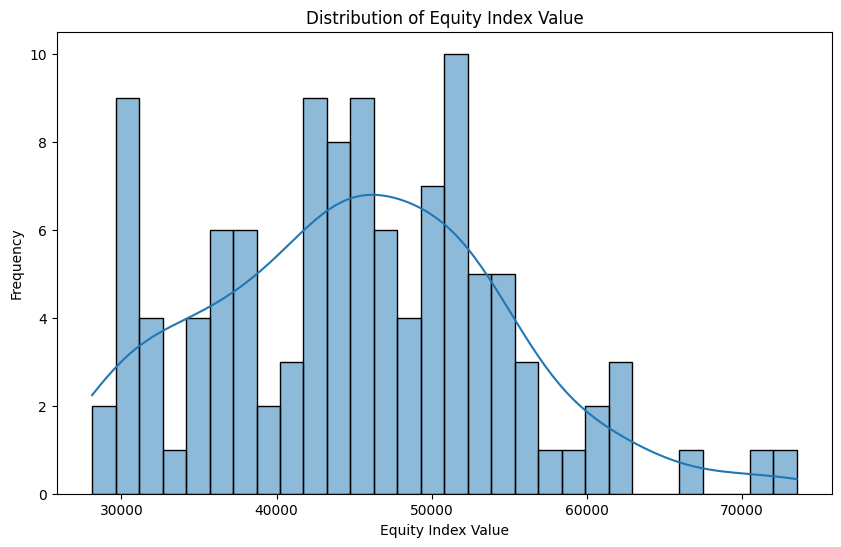

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

###### Variable 3A = Equity Index Value######
# Visualize the distribution of Equity Index Value
if 'df_income' in locals() and 'Equity Index Value' in df_income.columns:
    df_income['Equity Index Value_numeric'] = pd.to_numeric(
        df_income['Equity Index Value'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False),
        errors='coerce'
    )
    data_to_plot = df_income['Equity Index Value_numeric'].dropna()

    if not data_to_plot.empty:
        plt.figure(figsize=(10, 6))
        sns.histplot(data_to_plot, kde=True, bins=30)
        plt.title('Distribution of Equity Index Value')
        plt.xlabel('Equity Index Value')
        plt.ylabel('Frequency')
        plt.show()
    else:
        print("No valid numerical data found for plotting Equity Index Value.")
else:
    print("df_income or 'Equity Index Value' column not found for plotting.")



The distribution of equity index values appears somewhat right-skewed, as there are a few higher values extending the tail to the right. Most of the data points cluster between 35,000 and 55,000, forming the main peak of the distribution. The histogram does not perfectly follow a normal distribution, as it shows multiple smaller peaks and some irregularity. Overall, the data is moderately spread out with a tendency toward higher outliers.

/tmp/ipython-input-822439200.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




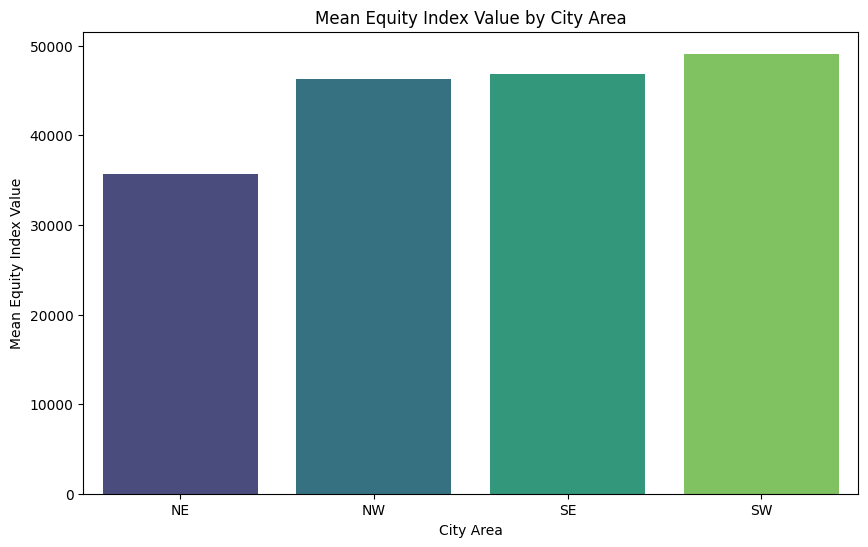

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'equity_summary_by_area' in locals() and not equity_summary_by_area.empty:

    plt.figure(figsize=(10, 6))
    sns.barplot(data=equity_summary_by_area, x='Area', y='mean', palette='viridis')
    plt.title('Mean Equity Index Value by City Area')
    plt.xlabel('City Area')
    plt.ylabel('Mean Equity Index Value')
    plt.show()


else:
    print("equity_summary_by_area not found or is empty. Please run the previous cell to generate the data.")

The chart shows the mean equity index values across different city areas. The Southwest (SW) has the highest mean value, approaching $49,000, while the Northeast (NE) has the lowest at around $36,000. The Northwest (NW) and Southeast (SE) areas are quite similar, both averaging around 46,000–47,000. Overall, the distribution suggests regional differences, with the SW outperforming other areas in equity index value.

### Visualize Speed Limits

In [ ]:
print("Data types:")
print(df_speedlimit.dtypes)
print("\nUnique values in 'speed' column:")
print(df_speedlimit['speed'].unique())


df_speedlimit_map = df_speedlimit.to_crs(epsg=4326)


df_speedlimit_map['speed'] = df_speedlimit_map['speed'].astype(str).str.extract('(\d+)', expand=False)
df_speedlimit_map['speed'] = pd.to_numeric(df_speedlimit_map['speed'], errors='coerce')


df_speedlimit_map = df_speedlimit_map.dropna(subset=['speed'])

print(f"\nSpeed range: {df_speedlimit_map['speed'].min()} to {df_speedlimit_map['speed'].max()}")


fig = px.scatter_mapbox(df_speedlimit_map,
                        lat=df_speedlimit_map.geometry.y,
                        lon=df_speedlimit_map.geometry.x,
                        hover_name="street_name",
                        hover_data={"speed": True, "distance": True},
                        color="speed",
                        color_continuous_scale="viridis",
                        range_color=[0, df_speedlimit_map['speed'].max()],
                        opacity=0.7,
                        center={"lat": 51.0486, "lon": -114.0708},
                        mapbox_style='open-street-map',
                        zoom=10,
                        title='Speed Limits in Calgary')

fig.update_layout(margin={"r":50,"t":50,"l":50,"b":50},
                  autosize=True,
                  height=600,
                  width=800)
fig.show()

Data types:
geometry       geometry
distance         object
speed             int64
street_name      object
dtype: object

Unique values in 'speed' column:
[ 60  30  70  80  90 100 110  50  40  20   0]

Speed range: 0 to 110


<>:10: SyntaxWarning:

invalid escape sequence '\d'

<>:10: SyntaxWarning:

invalid escape sequence '\d'

/tmp/ipython-input-3662954309.py:10: SyntaxWarning:

invalid escape sequence '\d'



Total points after cleaning: 3637
Points by quadrant:
quadrant
SW    1137
NE    1044
NW     891
SE     565
Name: count, dtype: int64


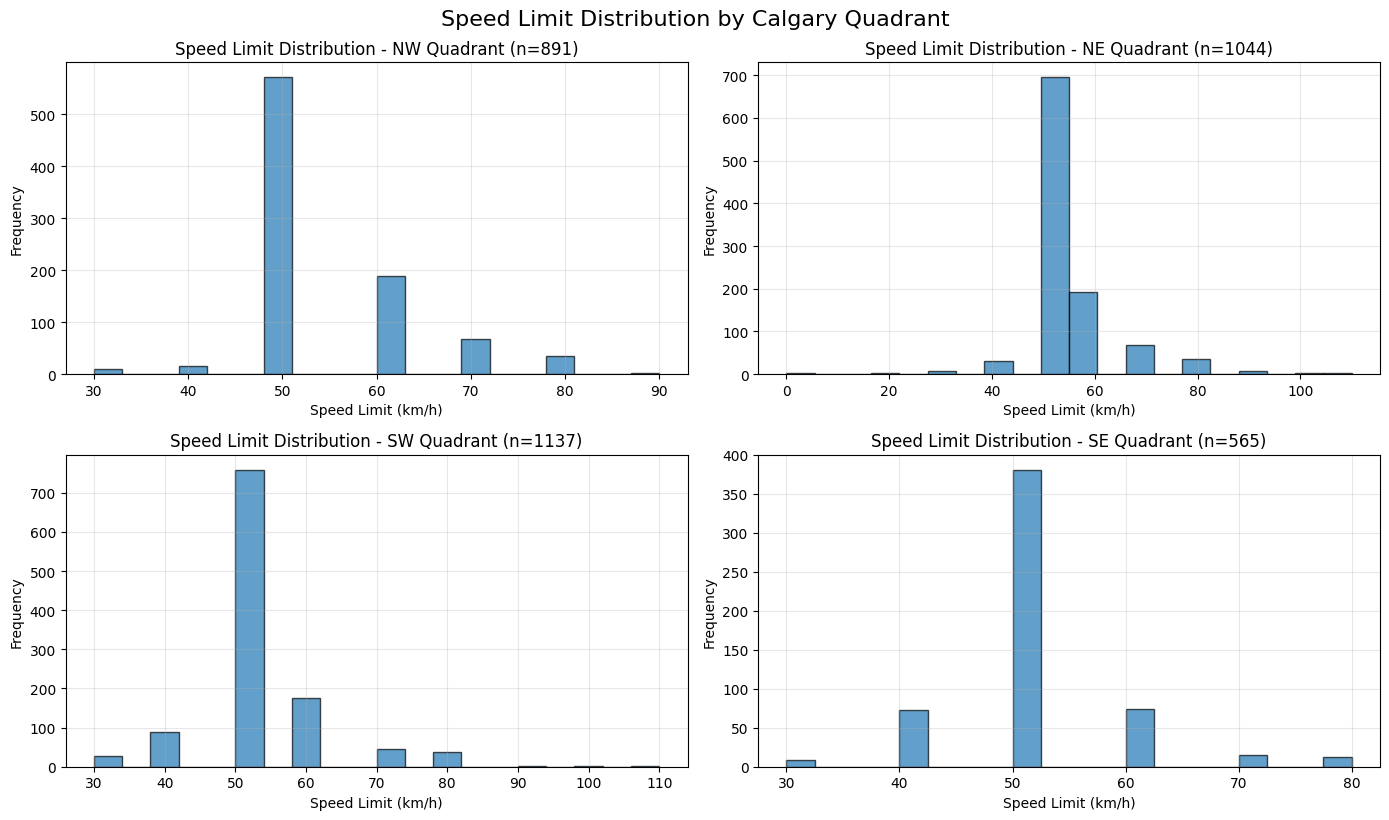


Speed Limit Statistics by Quadrant:
           count       mean       std   min   25%   50%   75%    max
quadrant                                                            
NE        1044.0  54.090038  9.665327   0.0  50.0  50.0  60.0  110.0
NW         891.0  54.545455  8.836270  30.0  50.0  50.0  60.0   90.0
SE         565.0  50.920354  7.936072  30.0  50.0  50.0  50.0   80.0
SW        1137.0  52.242744  9.105263  30.0  50.0  50.0  50.0  110.0


In [ ]:
calgary_center = {"lat": 51.0486, "lon": -114.0708}


df_speedlimit_quadrant = df_speedlimit.to_crs(epsg=4326).copy()

# Remove any rows with null geometries
df_speedlimit_quadrant = df_speedlimit_quadrant[df_speedlimit_quadrant.geometry.notna()]


def get_quadrant(geometry):
    if geometry is None:
        return None
    try:
        x, y = geometry.x, geometry.y
        if y >= calgary_center['lat']:
            return 'NE' if x < calgary_center['lon'] else 'NW'
        else:
            return 'SE' if x < calgary_center['lon'] else 'SW'
    except (AttributeError, TypeError):
        return None

df_speedlimit_quadrant['quadrant'] = df_speedlimit_quadrant.geometry.apply(get_quadrant)

# Remove any rows where quadrant is NULL
df_speedlimit_quadrant = df_speedlimit_quadrant.dropna(subset=['quadrant'])


df_speedlimit_quadrant['speed'] = pd.to_numeric(df_speedlimit_quadrant['speed'], errors='coerce')
df_speedlimit_quadrant = df_speedlimit_quadrant.dropna(subset=['speed'])

print(f"Total points after cleaning: {len(df_speedlimit_quadrant)}")
print(f"Points by quadrant:\n{df_speedlimit_quadrant['quadrant'].value_counts()}")

# Create histogram by quadrant
plt.figure(figsize=(14, 8))
for i, quadrant in enumerate(['NW', 'NE', 'SW', 'SE'], 1):
    plt.subplot(2, 2, i)
    quadrant_data = df_speedlimit_quadrant[df_speedlimit_quadrant['quadrant'] == quadrant]
    if len(quadrant_data) > 0:
        plt.hist(quadrant_data['speed'], bins=20, alpha=0.7, edgecolor='black')
        plt.title(f'Speed Limit Distribution - {quadrant} Quadrant (n={len(quadrant_data)})')
        plt.xlabel('Speed Limit (km/h)')
        plt.ylabel('Frequency')
        plt.grid(alpha=0.3)
    else:
        plt.text(0.5, 0.5, f'No data for {quadrant}',
                horizontalalignment='center', verticalalignment='center',
                transform=plt.gca().transAxes, fontsize=12)
        plt.title(f'Speed Limit Distribution - {quadrant} Quadrant')

plt.tight_layout()
plt.suptitle('Speed Limit Distribution by Calgary Quadrant', y=1.02, fontsize=16)
plt.show()

# Summary statistics by quadrant
print("\nSpeed Limit Statistics by Quadrant:")
print(df_speedlimit_quadrant.groupby('quadrant')['speed'].describe())

Total incidents with speed limit data: 5711
Unique speed limits: ['100', '30', '40', '50', '60', '70', '80', '90']


/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



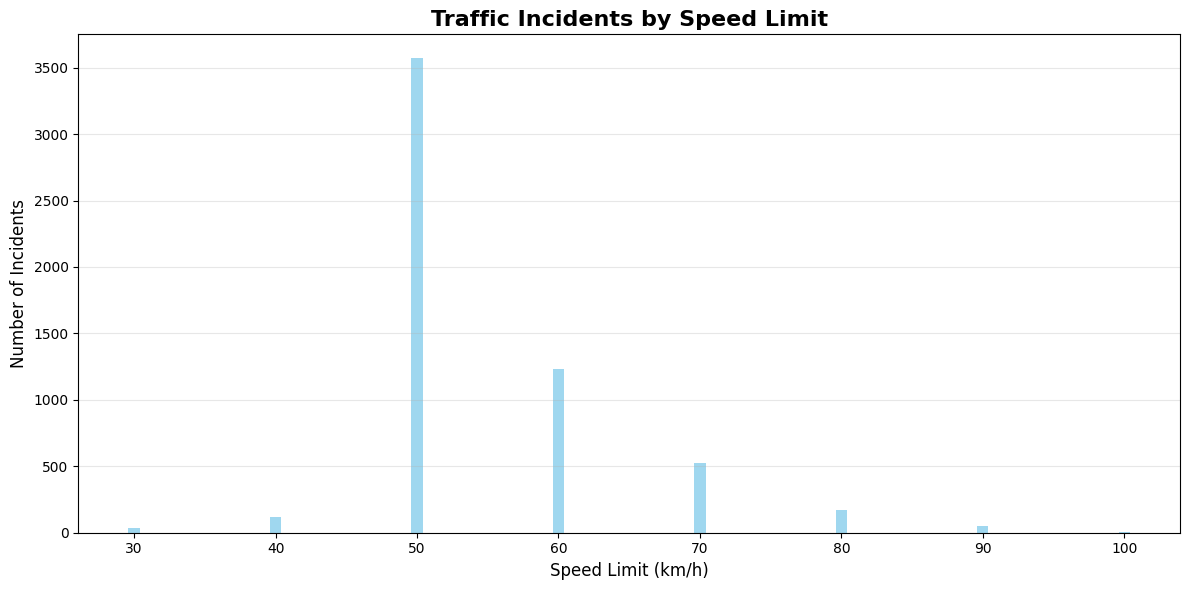

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use the full joined dataset, not just the sample
matched_incidents = df_joined_spatial[df_joined_spatial['speed_speedlimit'].notna()]

print(f"Total incidents with speed limit data: {len(matched_incidents)}")
print(f"Unique speed limits: {sorted(matched_incidents['speed_speedlimit'].unique())}")

plt.figure(figsize=(12, 6))

# Convert speed limits to numeric for proper sorting
matched_incidents['speed_limit_numeric'] = pd.to_numeric(matched_incidents['speed_speedlimit'], errors='coerce')

# Group by speed limit and count incidents
incidents_by_speed = matched_incidents.groupby('speed_limit_numeric').size().sort_index()

# Create the bar plot using the grouped data
plt.bar(incidents_by_speed.index, incidents_by_speed.values, color='skyblue', alpha=0.8)
plt.title('Traffic Incidents by Speed Limit', fontsize=16, fontweight='bold')
plt.xlabel('Speed Limit (km/h)', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)

# Set x-axis ticks to show all speed limits in proper numerical order
plt.xticks(incidents_by_speed.index)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

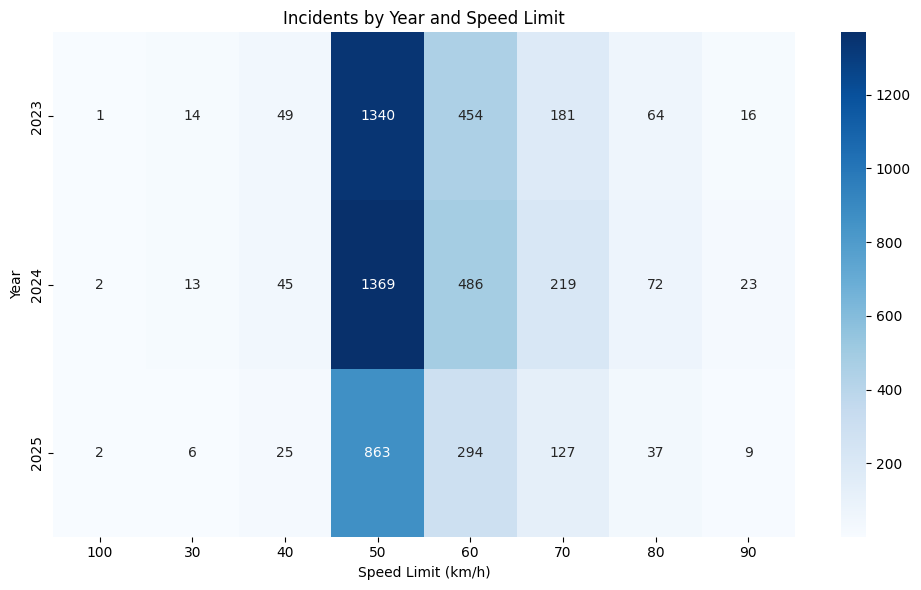

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create the pivot table
if 'Year' in matched_incidents.columns:
    year_speed_pivot = matched_incidents.pivot_table(
        values='Traffic Incident ID',
        index='Year',
        columns='speed_speedlimit',
        aggfunc='count',
        fill_value=0
    )

    # Create a single plot
    plt.figure(figsize=(10, 6))
    sns.heatmap(year_speed_pivot, annot=True, fmt='d', cmap='Blues')
    plt.title('Incidents by Year and Speed Limit')
    plt.xlabel('Speed Limit (km/h)')
    plt.ylabel('Year')
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(10, 6))
    plt.text(0.5, 0.5, 'Year data not available', ha='center', va='center')
    plt.title('Year Analysis (Not Available)')
    plt.show()

###Visualize Bikeway Characteristics

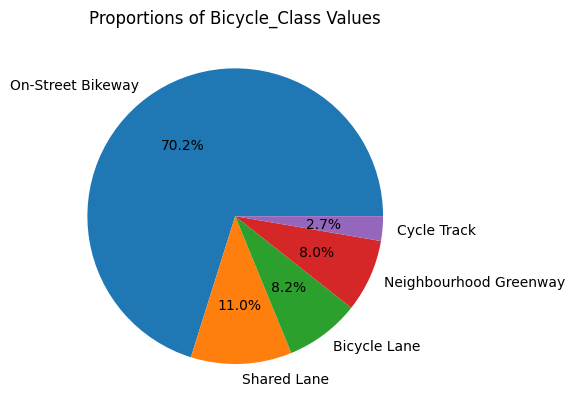

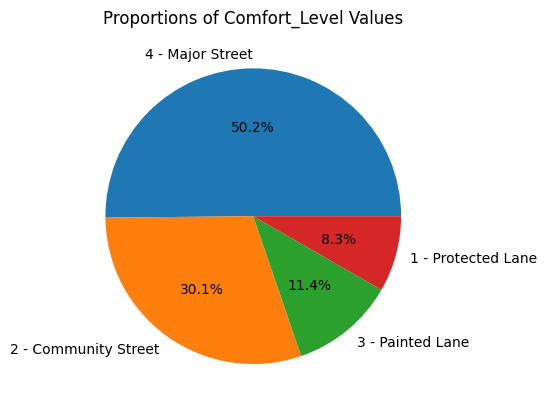

In [ ]:
# Pie chart of Bicycle_Class values
counts = bikeways_map['Bicycle_Class'].value_counts()
labels = bikeways_map['Bicycle_Class'].unique()
bicycle_class_df = pd.DataFrame({'counts': counts, 'labels': labels})
bicycle_class_df = bicycle_class_df[~bicycle_class_df['labels'].isin(["Temporary", "Decommissioned"])] # Drop small proportion values for cleanliness

plt.clf()
plt.pie(x = bicycle_class_df['counts'], labels = bicycle_class_df['labels'], autopct = '%1.1f%%')
plt.title("Proportions of Bicycle_Class Values")
plt.show()

# Pie chart of Comfort_Level values
counts = bikeways_map['Comfort_Level'].value_counts()
labels = counts.index.tolist()
comfort_level_df = pd.DataFrame({'counts': counts, 'labels': labels})

plt.clf()
plt.pie(x = comfort_level_df['counts'], labels = comfort_level_df['labels'], autopct = '%1.1f%%')
plt.title("Proportions of Comfort_Level Values")
plt.show()

As the bikeways_map dataset included only categorical variables, we were limited in what types of visualizations we could plot. With our primary goal for this dataset being examining the intersection with traffic_incidents, we decided that the best visualizations we could produce were pie charts showing the counts of selected variable values, specifically those that indicated in which type of environment bikeways were located (ie. do the bikeways operate on street or separated from traffic). The limitation to this is, as we will see in later steps, the type of environment the bikeways operate in is not the only factor influencing how bikeways interface with road traffic.

**Q1:** Explain your choice of plots using the five visualization components:
1. Data component -- what kinds of data are you dealing with?
2. Graphical component -- what kinds of plot can you use?
3. Label component -- what should be on the plot axis?
4. Esthetic component -- what should you plot say, and how best to do this?
5. Ethical component -- Is the graph misleading, what is left out?

# <font color='lightblue'>4. Correlations</font>

## Correlation of Traffic Incidents & Traffic Volume

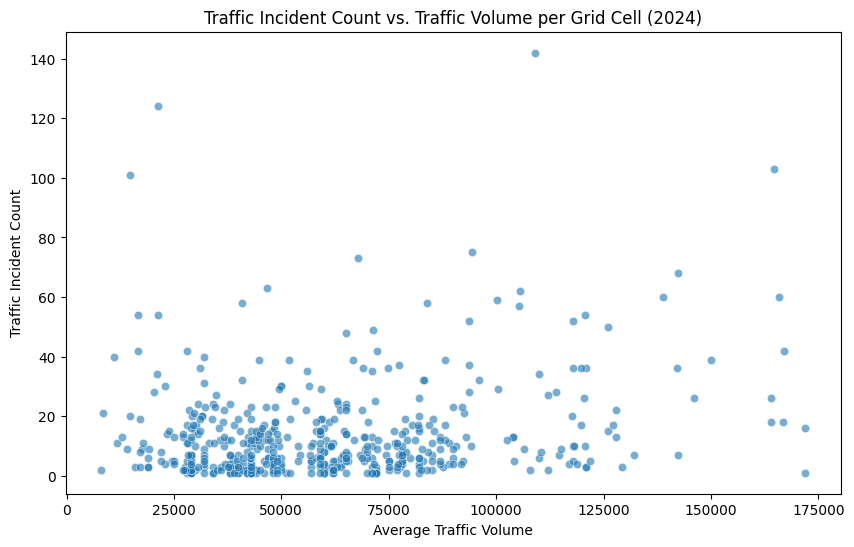

In [ ]:
# Filter df_combined for the year 2024
df_combined_2024 = df_combined[df_combined['Year'] == 2024].copy()

# Convert 'Traffic Volume' to numeric, coercing errors
df_combined_2024['Traffic Volume'] = pd.to_numeric(df_combined_2024['Traffic Volume'], errors='coerce')

# Aggregate data by grid cell to get incident count and average traffic volume
df_agg_corr = df_combined_2024.groupby(['X grid', 'Y grid']).agg(
    Incident_Count=('Traffic Incident ID', 'count'),
    Traffic_Volume=('Traffic Volume', 'mean')
).reset_index()

# Filter for average traffic volume of at least 35000
df_agg_corr_filtered = df_agg_corr[df_agg_corr['Traffic_Volume'] > 0].copy()

# Generate the scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_agg_corr_filtered, x='Traffic_Volume', y='Incident_Count', alpha=0.6)
plt.title('Traffic Incident Count vs. Traffic Volume per Grid Cell (2024)')
plt.xlabel('Average Traffic Volume')
plt.ylabel('Traffic Incident Count')
plt.show()

In [ ]:
# Calculate the correlation coefficient between Incident_Count and Traffic_Volume
correlation = df_agg_corr_filtered['Incident_Count'].corr(df_agg_corr_filtered['Traffic_Volume'])

# Print the correlation coefficient
print(f"Correlation coefficient between Traffic Incident Count and Traffic Volume: {correlation:.2f}")

Correlation coefficient between Traffic Incident Count and Traffic Volume: 0.22


Traffic Incidents and Traffic Volume exhibit a weak positive correlation of 0.22.  

There appears to be a relationship between the two variables - the scatter plot does not appear to be fully random. However, the correlation is not high enough to indicate that Traffic Volume is a dominant influence on the level of Traffic Incidents.

Likely there are other influential variables at play.  

The shape of the scatter plot also roughly suggests the variables may have a non-linear relationship

**Action:** Use correlation to estimate the relationship between some of the key variables. Try exploring for interesting relationships using heatmaps.

**Q2:** Choose one or two correlations and describe what the magnitude and direction of the correlation suggests about the relationship between the two variables.

## Correlation of Traffic Incidents and Bikeways

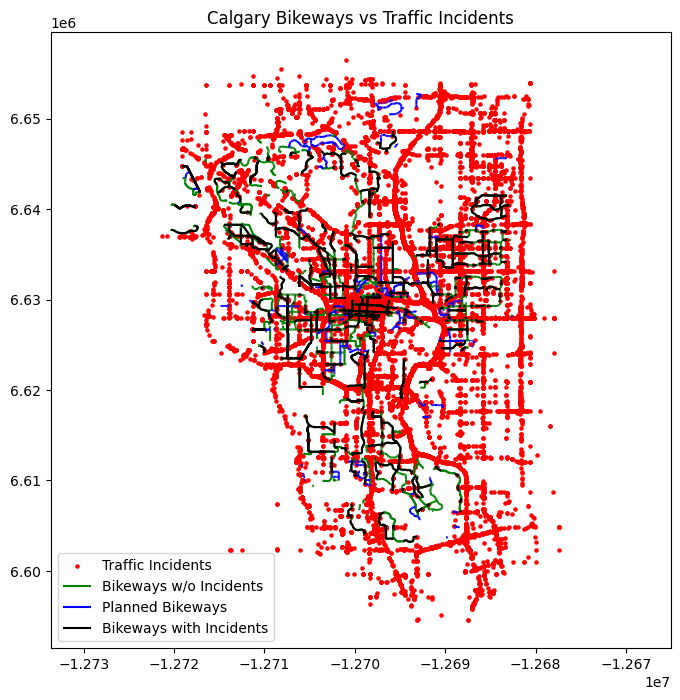

In [ ]:
# Create map showing the intersection between bikeways and traffic_incidents
fig = plt.figure()
axis = fig.add_subplot(1,1,1)

# # Plot three layers, raw data for bikeways and traffic incidents, plus the intersection of both
df_incidents.plot(ax=axis, markersize=5, color="red", label = "Traffic Incidents")
current_bikeways.plot(ax=axis, edgecolor='green', label = "Bikeways w/o Incidents")
planned_bikeways.plot(ax=axis, edgecolor="blue", label = "Planned Bikeways")
current_bikeways_incidents.plot(ax=axis, edgecolor="black", label = "Bikeways with Incidents")

plt.axis('equal')
plt.title('Calgary Bikeways vs Traffic Incidents')
plt.legend(loc="lower left")
fig.set_size_inches(8,8)

The map above shows the intersection of bicycle lanes with traffic incidents, showing where traffic incidents may potentially involve bikeways. Bikeways that intersect with traffic incidents are shown in black, while bikeways that don't intersect with traffic incidents are shown in green. Planned bikeways that don't yet exist are shown in blue, while all traffic incidents are shown as red dots.

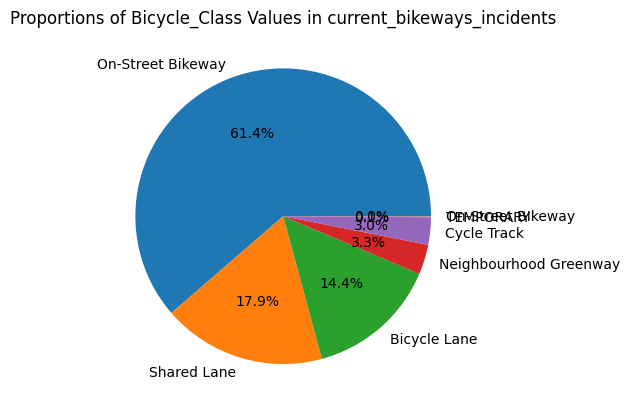

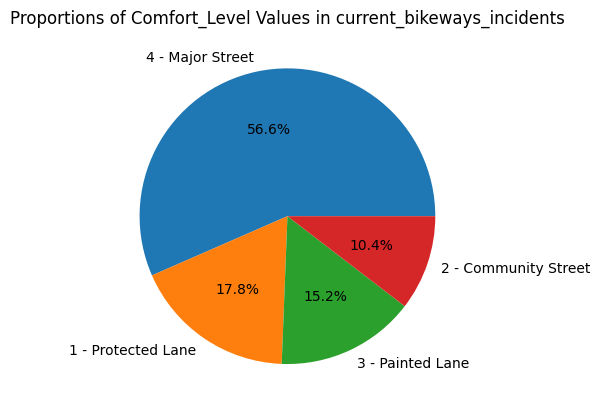

In [ ]:
# Pie chart of Bicycle_Class values
counts = current_bikeways_incidents['Bicycle_Class'].value_counts()
labels = current_bikeways_incidents['Bicycle_Class'].unique()
bicycle_class_incidents_df = pd.DataFrame({'counts': counts, 'labels': labels})

plt.clf()
plt.pie(x = bicycle_class_incidents_df['counts'], labels = bicycle_class_incidents_df['labels'], autopct = '%1.1f%%')
plt.title("Proportions of Bicycle_Class Values in current_bikeways_incidents")
plt.show()

# Pie chart of Comfort_Level values
counts = current_bikeways_incidents['Comfort_Level'].value_counts()
labels = counts.index.tolist()
comfort_level_incidents_df = pd.DataFrame({'counts': counts, 'labels': labels})

plt.clf()
plt.pie(x = comfort_level_incidents_df['counts'], labels = comfort_level_incidents_df['labels'], autopct = '%1.1f%%')
plt.title("Proportions of Comfort_Level Values in current_bikeways_incidents")
plt.show()

## Correlation of Area, Incident Count and Equity Index Value


In [ ]:
# Ensure df_incidents and df_income are in the same CRS for spatial join
df_incidents_proj = df_incidents.to_crs(epsg=32612)
df_income_proj = df_income.to_crs(epsg=32612)

incidents_with_equity = gpd.sjoin(df_incidents_proj, df_income_proj[['Equity Index Value_numeric', 'Area', 'geometry']], how='inner', predicate='within')

# Group by Area and calculate incident count and mean equity index value
area_correlation_data = incidents_with_equity.groupby('Area').agg(
    Incident_Count=('Traffic Incident ID', 'count'),
    Mean_Equity_Index_Value=('Equity Index Value_numeric', 'mean')
).reset_index()

print("Correlation data by Area:")
display(area_correlation_data)

# Calculate and display the correlation coefficient
correlation_area_incident_equity = area_correlation_data['Incident_Count'].corr(area_correlation_data['Mean_Equity_Index_Value'])
print(f"\nCorrelation coefficient between Incident Count and Mean Equity Index Value by Area: {correlation_area_incident_equity:.2f}")

Correlation data by Area:


,Area,Incident_Count,Mean_Equity_Index_Value
0,NE,6039,37153.989073
1,NW,3120,46537.361471
2,SE,5718,43174.042805
3,SW,4098,48702.508042



Correlation coefficient between Incident Count and Mean Equity Index Value by Area: -0.81


The correlation coefficient between Traffic Incident Count and Mean Equity Index Value by Area is -0.81. This indicates a strong negative correlation. It suggests that areas with a higher mean equity index value tend to have a lower number of traffic incidents, and conversely, areas with a lower mean equity index value tend to have a higher number of traffic incidents. For example, the NE area has the lowest mean equity index value (37,154) and the highest incident count (6037), while the SW area has the highest mean equity index value (48,698) and a lower incident count (4090). This strong negative relationship implies that economic factors, as represented by the equity index, may play a significant role in the frequency of traffic incidents within different areas of the city. Further investigation into the specific characteristics of areas with lower equity index values could help identify contributing factors to higher incident rates.

## Correlation of Area, Incident Count and Equity Index Value with More Detail

In [ ]:
# Ensure df_incidents and df_income are in the same CRS for spatial join
df_incidents_proj = df_incidents.to_crs(epsg=32612)
df_income_proj = df_income.to_crs(epsg=32612)

incidents_with_equity = gpd.sjoin(df_incidents_proj, df_income_proj[['Equity Index Value_numeric', 'Area', 'geometry']], how='inner', predicate='within')

# Calculate the correlation coefficient between Incident Count and Equity Index Value
# We need to ensure both columns are numeric and handle potential NaNs
incidents_with_equity['Equity Index Value_numeric'] = pd.to_numeric(incidents_with_equity['Equity Index Value_numeric'], errors='coerce')

# Drop rows with NaN in either column before calculating correlation
correlation_data = incidents_with_equity.dropna(subset=['Traffic Incident ID', 'Equity Index Value_numeric'])

# Calculate the correlation coefficient
correlation_incident_equity = correlation_data['Traffic Incident ID'].astype(str).str.len().corr(correlation_data['Equity Index Value_numeric'])


print(f"\nCorrelation coefficient between Traffic Incident Count and Equity Index Value: {correlation_incident_equity:.2f}")


Correlation coefficient between Traffic Incident Count and Equity Index Value: 0.00


##Correlation of Traffic Incidents and Speedlimits

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



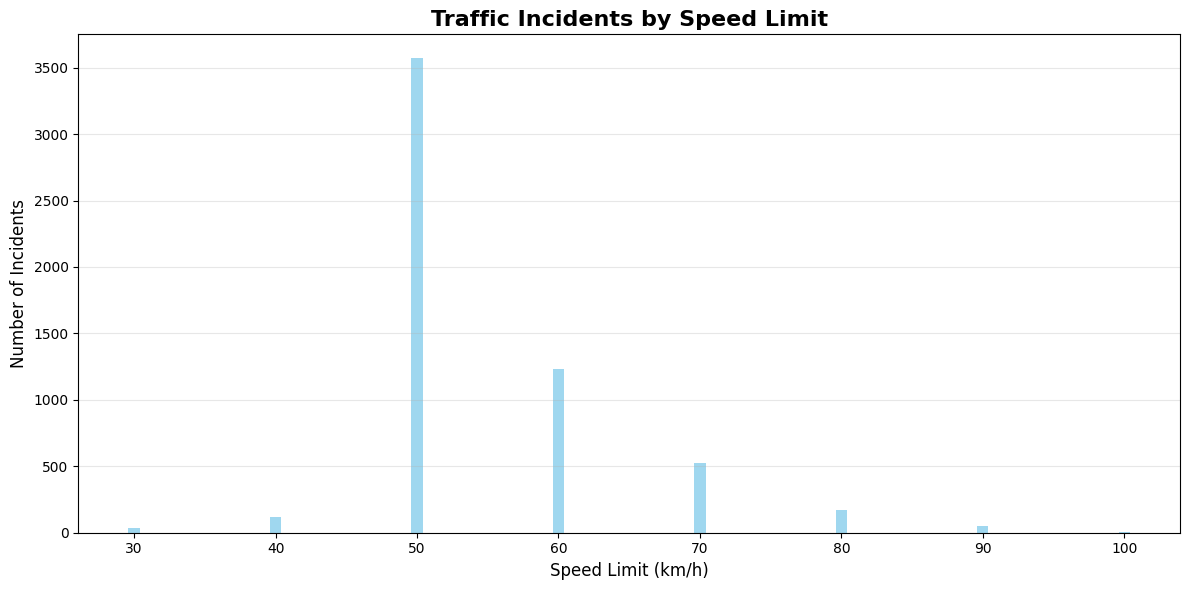

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use the full joined dataset, not just the sample
matched_incidents = df_joined_spatial[df_joined_spatial['speed_speedlimit'].notna()]

#print(f"Total incidents with speed limit data: {len(matched_incidents)}")
#print(f"Unique speed limits: {sorted(matched_incidents['speed_speedlimit'].unique())}")

plt.figure(figsize=(12, 6))

# Convert speed limits to numeric for proper sorting
matched_incidents['speed_limit_numeric'] = pd.to_numeric(matched_incidents['speed_speedlimit'], errors='coerce')

# Group by speed limit and count incidents
incidents_by_speed = matched_incidents.groupby('speed_limit_numeric').size().sort_index()

# Create the bar plot using the grouped data
plt.bar(incidents_by_speed.index, incidents_by_speed.values, color='skyblue', alpha=0.8)
plt.title('Traffic Incidents by Speed Limit', fontsize=16, fontweight='bold')
plt.xlabel('Speed Limit (km/h)', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)

# Set x-axis ticks to show all speed limits in proper numerical order
plt.xticks(incidents_by_speed.index)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

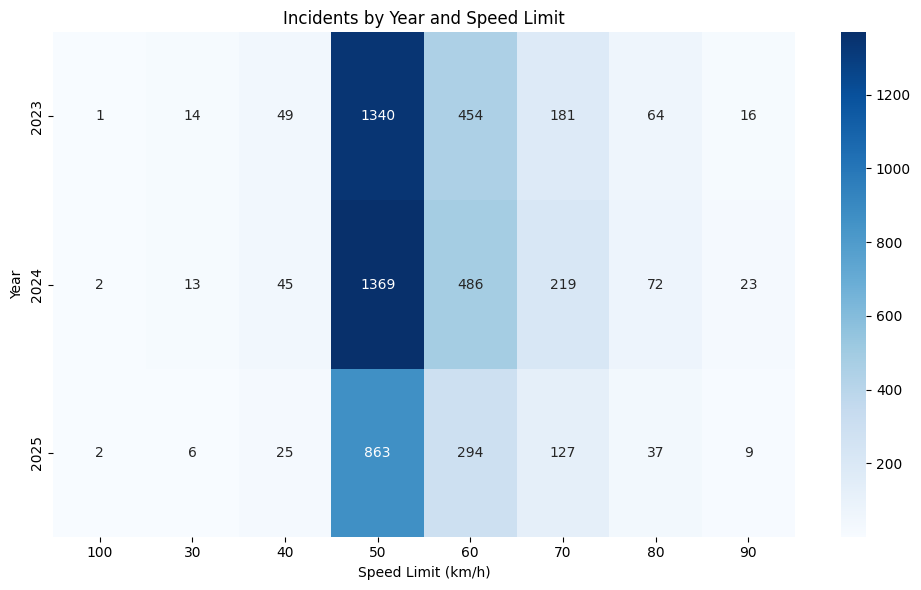

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create the pivot table
if 'Year' in matched_incidents.columns:
    year_speed_pivot = matched_incidents.pivot_table(
        values='Traffic Incident ID',
        index='Year',
        columns='speed_speedlimit',
        aggfunc='count',
        fill_value=0
    )

    # Create a single plot
    plt.figure(figsize=(10, 6))
    sns.heatmap(year_speed_pivot, annot=True, fmt='d', cmap='Blues')
    plt.title('Incidents by Year and Speed Limit')
    plt.xlabel('Speed Limit (km/h)')
    plt.ylabel('Year')
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(10, 6))
    plt.text(0.5, 0.5, 'Year data not available', ha='center', va='center')
    plt.title('Year Analysis (Not Available)')
    plt.show()

There's an obvious pattern between speed limits and where accidents happen.
The big takeaway is 50 km/h zones are accident magnets. That first chart shows they get hit with around 3,500 incidents - way more than anywhere else. The 60 km/h zones come in second but it's not even close.
What's interesting is how the numbers drop off as speed limits go up. You'd think faster roads would be more dangerous, right? But 70, 80, 90, and 100 km/h zones all have relatively few accidents compared to those 50 km/h areas.
The second chart backs this up - from 2020 to 2022, it's the same story every year. Those 50 km/h zones consistently rack up over 1,300 incidents annually.
Here's what's probably going on: 50 km/h roads are your typical city streets. They're packed with stop signs, traffic lights, people turning left across traffic, pedestrians crossing, cyclists, delivery trucks double-parking - you name it. It's chaos compared to a highway where everyone's just going straight at roughly the same speed.
So while you might assume "faster = more dangerous," the reality is that complicated urban driving environments cause way more problems than high-speed highways. It's not really about the speed limit itself - it's about everything else happening on those roads.

# <font color='lightblue'>5. Discussion</font>

**Q3:** Did this exploratory data analysis help you better understand your chosen dataset? If so how? Is there still parts that don't make sense?
> The idea with this question is not to see if you know everything about this dataset, just how EDA might have helped (or not!).

## Traffic Incidents and Volumes

The exploratory data analysis was helpful in understanding the range of normal values within the data set, and better understanding their proper interpretation.

For instance, although the joins were made properly and by careful design, statements like the following were difficult to make before spending time exploring the data: "The average 1km block's closest road observes the following summary statistics regarding the quantity of daily vehicles: 108571.4 daily vehicles on average"

Statements like that were difficult to make, because in practice it's hard to describe that kind of relationship properly. Interpreted correctly, there is definitely value in metrics such as that, but there is also substantial risk of misinterpretation (such as summing up all of the traffic volumes, even though the same values duplicate across different traffic incidents)

Particularly, it was useful to see that there is some observable clustering, with more incidents occuring in a certain low-volume region (40-60k traffic volume). It is useful also to get an initial idea of the typical values of each metric, and then visualize them (in a bar chart or otherwise)

Visualizing across maps also helped to see at a high level whether the amount of data seemed to match the entire city. Experiencing the pain points of 1) Having no data show up in the Calgary map vs. 2) Having relative calculations fail demonstrated the importance of managing geographic vs. projected CRS properly

##Traffic Incidents and Bicycle Lanes

While the dataset showing bikeways had scant useful variables for generating summary statistics, we were still able to gather some useful insights, such as the fact that a majority of bikeways are located on-street, and particularly on major streets, which supports our hypothesis that traffic incidents could coincide with and involve bikeways.

By joining the bikeways dataset with the traffic incidents dataset, we were able to get experience with joining data based on geometry, which we were initially uncertain about how to approach. The sjoin function found in GeoPandas was actually fairly simple to use, and we accounted for potential inaccuracy in the precision of geo points by using the sjoin_nearby function and including a buffer distance (we used 50m to keep some precision in calculating the intersection of the two datasets).

On mapping the intersection of the two datasets, we came to some surprising and not so surprising conclusions. First, we observed that a large proportion of bikeways do intersect with traffic incidents, at least spatially if not necessarily literally. However, there were also a large number of bikeways that do not intersect with traffic incidents. Upon further inspection, we also found that a disproportionate number of bikeways that intersect with traffic incidents are shared lane bikeways and bicycle lane bikeways, and furthermore, a disproportionate number of bikeways are of the Major Street, Painted Lane, and Protected Lane comfort levels, which may be an indicator of a non-spurious relationship. However, there were disproportionately fewer bikeways classed as On-Street Bikeways that showed up in the intersecting data, which we will need to consider further.

Finally, there were some limitations we observed. Upon mapping the intersecting data, we found that while there were some datapoints that were finely delineated between portions that did and did not intersect, we also found that some bikeways showed up in the intersecting data despite only having one or a few points that intersected, which can be seen as any black line that does not overlap one or more red dots. We will also need to consider how to deal with this issue going forward.


## Correlation of Area, Incident Count and Equity Index Value

The exploratory data analysis was helpful in understanding the range of normal values within the data set, and better understanding their proper interpretation. The spatial join of different datasets, particularly integrating the equity index with traffic incidents, revealed a strong negative correlation (-0.81) between the mean equity index value of an area and its traffic incident count. This finding was a significant insight provided by the EDA, suggesting that economic factors may play a crucial role in incident frequency across the city. While the quantitative correlation is clear, understanding the underlying reasons for this relationship, such as infrastructure disparities or traffic patterns in lower-equity areas, still requires further investigation. EDA helped identify this key relationship and highlighted areas where deeper analysis is needed to fully grasp the dynamics at play.

##Traffic Incidents and Speed Limits

Working with the speed limit dataset presented several data quality challenges. We encountered significant NaN values in both geometry fields and speed limit columns, forcing us to drop records with missing location data. Speed limit values were inconsistent - some stored as text with "km/h" suffixes, others had impossible values like 0 or extremely high numbers that required cleaning.
We used GeoPandas for spatial operations, particularly the sjoin and sjoin_nearby functions to handle geometry-based joins between speed limits and traffic incidents. Since road segments don't align perfectly with incident points, we applied a 50-meter buffer distance to capture incidents occurring "near" specific speed limit zones rather than requiring exact matches. This approach helped account for GPS precision issues but introduced some uncertainty about the true spatial relationships.
The dataset had incomplete road coverage, meaning not every incident could be matched to a speed limit value. We also had to standardize the speed limit format by converting text values to numeric and removing unit suffixes. Despite these limitations and the data we lost during cleaning, we still identified the clear pattern of 50 km/h zones having the highest incident concentrations.